# Data Sience Project: LSTM to predict the movement of stocks

## GPU Test

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available via tf.config:", tf.config.list_physical_devices('GPU'))

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

2025-06-23 08:57:18.729147: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 08:57:18.744081: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-23 08:57:18.762256: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 08:57:18.767681: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 08:57:18.780884: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.17.0
Built with CUDA: True
GPU available via tf.config: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16770549780727859367
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 32646561792
locality {
  bus_id: 1
  links {
  }
}
incarnation: 343007369163139872
physical_device_desc: "device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:5e:00.0, compute capability: 7.0"
xla_global_id: 416903419
]


2025-06-23 08:57:21.199731: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:5e:00.0, compute capability: 7.0


### ML Script

## Combined script all stocks

In [15]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from collections import Counter
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=15,            # number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,
    verbose=1
)

# GPU memory handling
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
tf.keras.backend.clear_session()
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# === Parameters ===
time_steps = 40
forward_days = 5
classes = 5
folder_path = "stocks"  # Pfad zum Ordner mit CSVs

# === Features ===
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'MA10', 'MA20', 'MA50', 'MACD_ml', 'MACD_his', 
            'RSI14', 'OBV', 'ATR', 'StochasticMomentum']

X_all, y_all = [], []

# === Hilfsfunktion: Feature-Engineering ===
def process_stock(df):
    df = df.sort_values('Date').reset_index(drop=True)
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_his'] = df['MACD'] - df['MACD_signal']
    df.dropna(inplace=True)
    df = df.reset_index(drop=True)

    # Füge Dummy-Spalten hinzu, wenn du sie brauchst
    for f in features:
        if f not in df.columns:
            df[f] = 0.0

    # Skaliere nur die Features
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[features])

    X, y = [], []
    for i in range(len(scaled) - time_steps - forward_days):
        X.append(scaled[i:i+time_steps])
        curr = df['Close'].iloc[i+time_steps-1]
        future = df['Close'].iloc[i+time_steps+forward_days-1]
        pct = (future - curr) / curr * 100
        if pct <= -2:
            label = 0
        elif -2 < pct <= -0.5:
            label = 1
        elif -0.5 < pct < 0.5:
            label = 2
        elif 0.5 <= pct < 2:
            label = 3
        else:
            label = 4
        y.append(label)

    return np.array(X), np.array(y)

# === Alle Dateien im Ordner verarbeiten ===
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        try:
            df = pd.read_csv(os.path.join(folder_path, file), parse_dates=['Date'])
            X_part, y_part = process_stock(df)
            if len(X_part) > 0:
                X_all.append(X_part)
                y_all.append(y_part)
                print(f"{file}: {len(X_part)} samples")
        except Exception as e:
            print(f"Fehler bei Datei {file}: {e}")

# === Kombinieren ===
X = np.vstack(X_all)
y = np.hstack(y_all)

# === Resampling ===
X_reshaped = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = BorderlineSMOTE(kind='borderline-2').fit_resample(X_reshaped, y)
X_resampled = X_resampled.reshape(-1, time_steps, len(features))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.1, random_state=42)

# === Modell ===
def Create_LSTM_Model(units=256, drop_out=0.5, lr=5e-4):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(time_steps, len(features)), return_sequences=True))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(LSTM(units=units))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation='tanh'))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=5, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# === Training ===
model = Create_LSTM_Model()

history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# === Evaluation ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

print("Per-class accuracy:")
for i in np.unique(y_test):
    if i < conf_mat.shape[0]:
        acc = 100 * conf_mat[i, i] / sum(conf_mat[i]) if sum(conf_mat[i]) > 0 else 0
        print(f"Label {i} accuracy: {acc:.1f}%")






Num GPUs Available: 1
NVDA.csv: 104 samples
META.csv: 104 samples
AMZN.csv: 104 samples
HOOD.csv: 104 samples
TSLA.csv: 104 samples
GOOGL.csv: 104 samples
PLTR.csv: 104 samples
AAPL.csv: 104 samples
UBER.csv: 104 samples
MSFT.csv: 104 samples
Epoch 1/400


/opt/conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.2150 - loss: 2.2004 - val_accuracy: 0.3028 - val_loss: 1.5852
Epoch 2/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2623 - loss: 1.9584 - val_accuracy: 0.3349 - val_loss: 1.5655
Epoch 3/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3070 - loss: 1.8278 - val_accuracy: 0.2982 - val_loss: 1.5583
Epoch 4/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3114 - loss: 1.7713 - val_accuracy: 0.3211 - val_loss: 1.5487
Epoch 5/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3300 - loss: 1.7038 - val_accuracy: 0.3899 - val_loss: 1.5284
Epoch 6/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3659 - loss: 1.6259 - val_accuracy: 0.3211 - val_loss: 1.5252
Epoch 7/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3726 - loss: 1.5838 - val_accuracy: 0.3624 - val_loss: 1.4998
Epoch 8/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3858 - loss: 1.5551 - val_accuracy: 0.4083 - val_loss: 1.4731
Epoc

## Plots

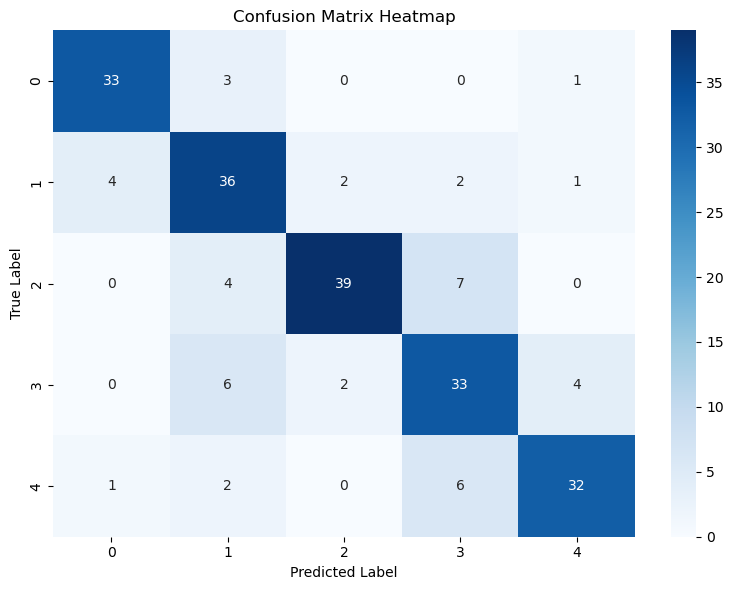

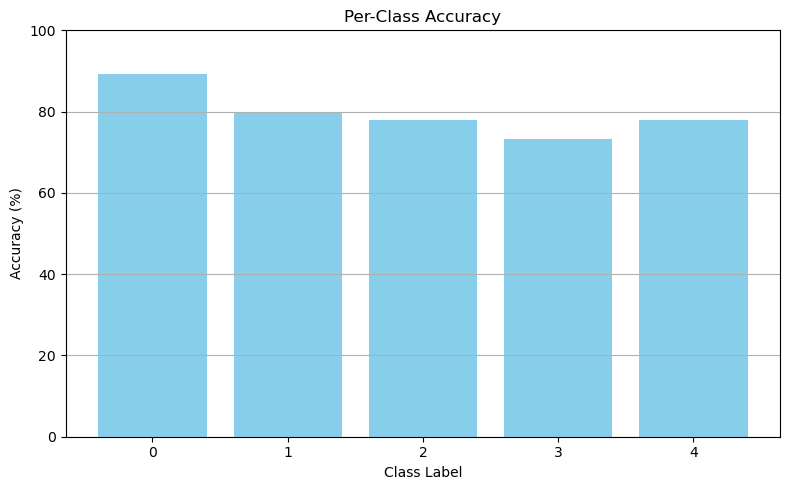

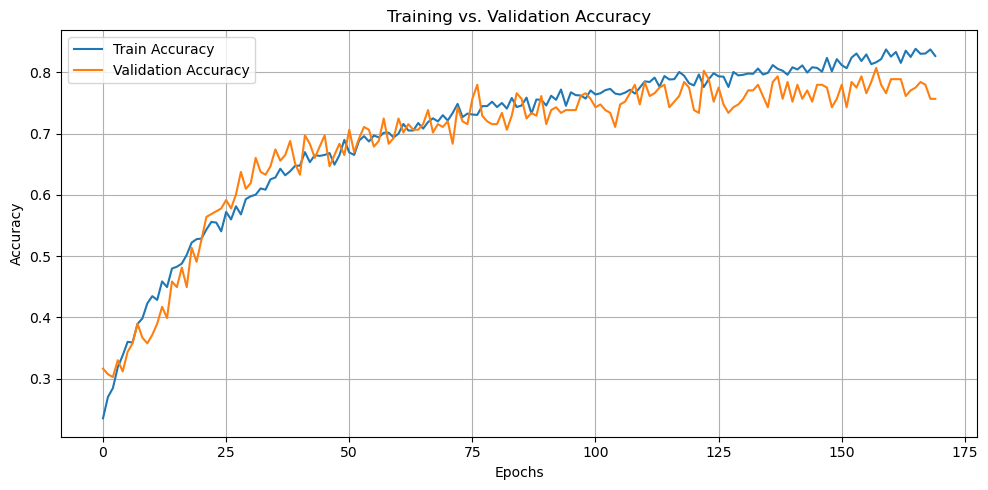

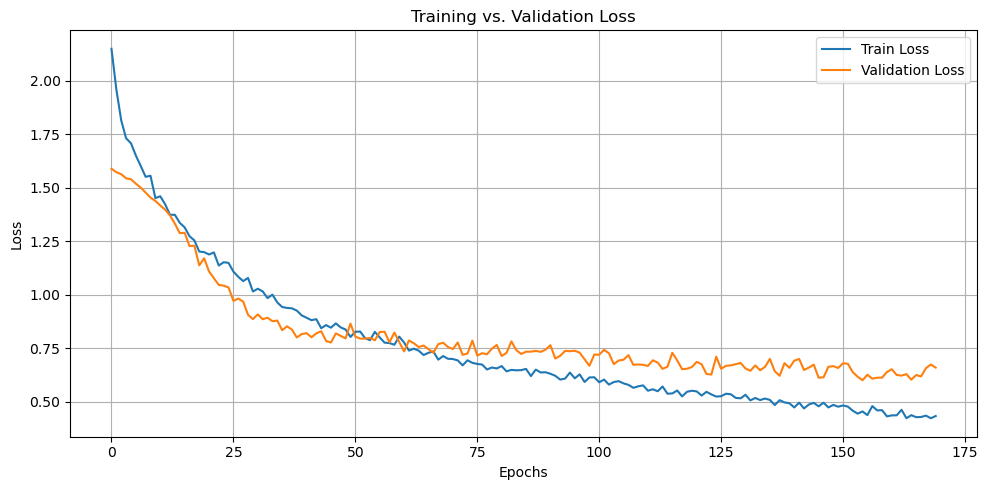

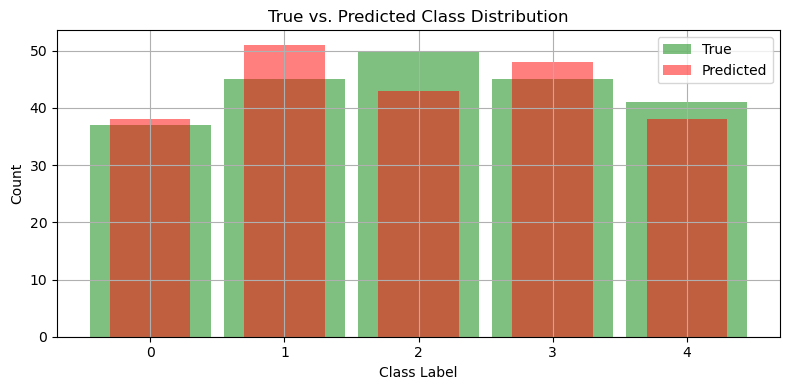

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Create a folder for plots
plot_dir = "plots"
os.makedirs(plot_dir, exist_ok=True)

# === Confusion Matrix Heatmap ===
def plot_confusion_matrix_heatmap(conf_mat):
    plt.figure(figsize=(8, 6))
    labels = [0, 1, 2, 3, 4]
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix Heatmap")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "confusion_matrix_heatmap.png"))
    plt.show()

# === Per-Class Accuracy Bar Chart ===
def plot_per_class_accuracy(conf_mat):
    labels = [0, 1, 2, 3, 4]
    per_class_acc = [100 * conf_mat[i, i] / sum(conf_mat[i]) if sum(conf_mat[i]) > 0 else 0 for i in labels]
    
    plt.figure(figsize=(8, 5))
    plt.bar(labels, per_class_acc, color="skyblue")
    plt.ylim(0, 100)
    plt.xlabel("Class Label")
    plt.ylabel("Accuracy (%)")
    plt.title("Per-Class Accuracy")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "per_class_accuracy.png"))
    plt.show()

# === Training vs Validation Accuracy ===
def plot_training_validation_accuracy(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training vs. Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "training_vs_validation_accuracy.png"))
    plt.show()

# === Training vs Validation Loss ===
def plot_training_validation_loss(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs. Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "training_vs_validation_loss.png"))
    plt.show()

# === Prediction vs True Class Distribution ===
def plot_prediction_distribution(y_test, y_pred):
    labels = [0, 1, 2, 3, 4]
    plt.figure(figsize=(8, 4))
    plt.hist(y_test, bins=np.arange(6)-0.5, alpha=0.5, label="True", color='g', rwidth=0.9)
    plt.hist(y_pred, bins=np.arange(6)-0.5, alpha=0.5, label="Predicted", color='r', rwidth=0.6)
    plt.xticks(labels)
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.title("True vs. Predicted Class Distribution")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "true_vs_predicted_distribution.png"))
    plt.show()

# === Run and Save All Plots ===
plot_confusion_matrix_heatmap(conf_mat)
plot_per_class_accuracy(conf_mat)
plot_training_validation_accuracy(history)
plot_training_validation_loss(history)
plot_prediction_distribution(y_test, y_pred)


In [4]:
!pip install imblearn

## GOLD

In [8]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from collections import Counter
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=15,            # number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,
    verbose=1
)

# GPU memory handling
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
tf.keras.backend.clear_session()
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# === Parameters ===
time_steps = 40
forward_days = 5
classes = 5
folder_path = "gold"  # Pfad zum Ordner mit CSVs

# === Features ===
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'MA10', 'MA20', 'MA50', 'MACD_ml', 'MACD_his', 
            'RSI14', 'OBV', 'ATR', 'StochasticMomentum']

X_all, y_all = [], []

# === Hilfsfunktion: Feature-Engineering ===
def process_stock(df):
    df = df.sort_values('Date').reset_index(drop=True)
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_his'] = df['MACD'] - df['MACD_signal']
    df.dropna(inplace=True)
    df = df.reset_index(drop=True)

    # Füge Dummy-Spalten hinzu, wenn du sie brauchst
    for f in features:
        if f not in df.columns:
            df[f] = 0.0

    # Skaliere nur die Features
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[features])

    X, y = [], []
    for i in range(len(scaled) - time_steps - forward_days):
        X.append(scaled[i:i+time_steps])
        curr = df['Close'].iloc[i+time_steps-1]
        future = df['Close'].iloc[i+time_steps+forward_days-1]
        pct = (future - curr) / curr * 100
        if pct <= -2:
            label = 0
        elif -2 < pct <= -0.5:
            label = 1
        elif -0.5 < pct < 0.5:
            label = 2
        elif 0.5 <= pct < 2:
            label = 3
        else:
            label = 4
        y.append(label)

    return np.array(X), np.array(y)

# === Alle Dateien im Ordner verarbeiten ===
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        try:
            df = pd.read_csv(os.path.join(folder_path, file), parse_dates=['Date'])
            X_part, y_part = process_stock(df)
            if len(X_part) > 0:
                X_all.append(X_part)
                y_all.append(y_part)
                print(f"{file}: {len(X_part)} samples")
        except Exception as e:
            print(f"Fehler bei Datei {file}: {e}")

# === Kombinieren ===
X = np.vstack(X_all)
y = np.hstack(y_all)

# === Resampling ===
X_reshaped = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = BorderlineSMOTE(kind='borderline-2').fit_resample(X_reshaped, y)
X_resampled = X_resampled.reshape(-1, time_steps, len(features))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.1, random_state=42)

# === Modell ===
def Create_LSTM_Model(units=128, drop_out=0.5, lr=5e-4):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(time_steps, len(features)), return_sequences=True))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(LSTM(units=units))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation='tanh'))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=5, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# === Training ===
model = Create_LSTM_Model()

history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# === Evaluation ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

print("Per-class accuracy:")
for i in np.unique(y_test):
    if i < conf_mat.shape[0]:
        acc = 100 * conf_mat[i, i] / sum(conf_mat[i]) if sum(conf_mat[i]) > 0 else 0
        print(f"Label {i} accuracy: {acc:.1f}%")






Num GPUs Available: 1
GC=F.csv: 104 samples
Epoch 1/400


/opt/conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2077 - loss: 2.2185 - val_accuracy: 0.2667 - val_loss: 1.5747
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3000 - loss: 1.9267 - val_accuracy: 0.5333 - val_loss: 1.5583
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2923 - loss: 1.8997 - val_accuracy: 0.5333 - val_loss: 1.5439
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2615 - loss: 1.8686 - val_accuracy: 0.5333 - val_loss: 1.5304
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3308 - loss: 1.7250 - val_accuracy: 0.5333 - val_loss: 1.5158
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2923 - loss: 1.7282 - val_accuracy: 0.6000 - val_loss: 1.5034
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3385 - loss: 1.7013 - val_accuracy: 0.4667 - val_loss: 1.4919
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3000 - loss: 1.6606 - val_accuracy: 0.5333 - val_loss: 1.4805
Epoch 

## BITCOIN

In [9]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from collections import Counter
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=15,            # number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,
    verbose=1
)

# GPU memory handling
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
tf.keras.backend.clear_session()
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# === Parameters ===
time_steps = 40
forward_days = 5
classes = 5
folder_path = "BTC"  # Pfad zum Ordner mit CSVs

# === Features ===
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'MA10', 'MA20', 'MA50', 'MACD_ml', 'MACD_his', 
            'RSI14', 'OBV', 'ATR', 'StochasticMomentum']

X_all, y_all = [], []

# === Hilfsfunktion: Feature-Engineering ===
def process_stock(df):
    df = df.sort_values('Date').reset_index(drop=True)
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_his'] = df['MACD'] - df['MACD_signal']
    df.dropna(inplace=True)
    df = df.reset_index(drop=True)

    # Füge Dummy-Spalten hinzu, wenn du sie brauchst
    for f in features:
        if f not in df.columns:
            df[f] = 0.0

    # Skaliere nur die Features
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[features])

    X, y = [], []
    for i in range(len(scaled) - time_steps - forward_days):
        X.append(scaled[i:i+time_steps])
        curr = df['Close'].iloc[i+time_steps-1]
        future = df['Close'].iloc[i+time_steps+forward_days-1]
        pct = (future - curr) / curr * 100
        if pct <= -2:
            label = 0
        elif -2 < pct <= -0.5:
            label = 1
        elif -0.5 < pct < 0.5:
            label = 2
        elif 0.5 <= pct < 2:
            label = 3
        else:
            label = 4
        y.append(label)

    return np.array(X), np.array(y)

# === Alle Dateien im Ordner verarbeiten ===
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        try:
            df = pd.read_csv(os.path.join(folder_path, file), parse_dates=['Date'])
            X_part, y_part = process_stock(df)
            if len(X_part) > 0:
                X_all.append(X_part)
                y_all.append(y_part)
                print(f"{file}: {len(X_part)} samples")
        except Exception as e:
            print(f"Fehler bei Datei {file}: {e}")

# === Kombinieren ===
X = np.vstack(X_all)
y = np.hstack(y_all)

# === Resampling ===
X_reshaped = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = BorderlineSMOTE(kind='borderline-2').fit_resample(X_reshaped, y)
X_resampled = X_resampled.reshape(-1, time_steps, len(features))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.1, random_state=42)

# === Modell ===
def Create_LSTM_Model(units=128, drop_out=0.5, lr=5e-4):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(time_steps, len(features)), return_sequences=True))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(LSTM(units=units))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation='tanh'))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=5, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# === Training ===
model = Create_LSTM_Model()

history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# === Evaluation ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

print("Per-class accuracy:")
for i in np.unique(y_test):
    if i < conf_mat.shape[0]:
        acc = 100 * conf_mat[i, i] / sum(conf_mat[i]) if sum(conf_mat[i]) > 0 else 0
        print(f"Label {i} accuracy: {acc:.1f}%")






Num GPUs Available: 1
BTC-USD.csv: 194 samples
Epoch 1/400


/opt/conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 0.1938 - loss: 2.2453 - val_accuracy: 0.2222 - val_loss: 1.6011
Epoch 2/400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2364 - loss: 2.1186 - val_accuracy: 0.3556 - val_loss: 1.5916
Epoch 3/400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2440 - loss: 2.0205 - val_accuracy: 0.3333 - val_loss: 1.5880
Epoch 4/400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2896 - loss: 1.9255 - val_accuracy: 0.3333 - val_loss: 1.5863
Epoch 5/400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3171 - loss: 1.8413 - val_accuracy: 0.3333 - val_loss: 1.5831
Epoch 6/400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3293 - loss: 1.8000 - val_accuracy: 0.3333 - val_loss: 1.5797
Epoch 7/400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3110 - loss: 1.7805 - val_accuracy: 0.3556 - val_loss: 1.5769
Epoch 8/400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3175 - loss: 1.7798 - val_accuracy: 0.3556 - val_loss: 1.5751
Epo